#EXPERIMENT - 2
Predicting Housing Prices: Develop a regression model to predict house prices based on features like location, size, and amenities.

In [ ]:
# ==============================
# 1. Import Libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

These libraries and tools are used to handle data (pandas, numpy), visualize results (matplotlib), preprocess and split datasets (sklearn utilities), build a Linear Regression model, and evaluate its performance using MAE, MSE, and R² score.

In [ ]:
# ==============================
# 2. Load Dataset
# ==============================

data = pd.read_csv("/content/drive/MyDrive/ML LAB EXPERIMENTS/Housing_Price_Dataset_120_Records.csv")

print(data.head())
print("\nDataset Info:\n")
print(data.info())


  HouseID  Location  Area_sqft  Bedrooms  Bathrooms  Balcony  Parking  \
0    H001     Rural       1028         1          3        0        0   
1    H002     Rural       2316         1          4        0        0   
2    H003     Urban       1834         1          2        2        2   
3    H004     Urban       1719         3          1        0        2   
4    H005  Suburban       1118         2          3        0        0   

   Age_Years Furnished   Price  
0          5       Yes   55.84  
1          3       Yes  103.88  
2         23        No   86.42  
3         14        No   96.77  
4         13       Yes   63.94  

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   HouseID    120 non-null    object 
 1   Location   120 non-null    object 
 2   Area_sqft  120 non-null    int64  
 3   Bedrooms   120 non-null    int64  
 4

This code loads the housing dataset from a CSV file into a pandas DataFrame and displays the first few rows along with dataset structure details like columns, data types, and missing values.

In [ ]:
data = data.drop("HouseID", axis=1)

X = data.drop("Price", axis=1)
y = data["Price"]

categorical_features = ["Location", "Furnished"]

numerical_features = [
    "Area_sqft",
    "Bedrooms",
    "Bathrooms",
    "Balcony",
    "Parking",
    "Age_Years"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)


This code removes the unnecessary HouseID column, separates input features (X) and target variable (Price), identifies categorical and numerical columns, and creates a preprocessing step that applies One-Hot Encoding to categorical features while keeping numerical features unchanged.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


This code splits the dataset into training and testing sets, using 80% of the data for training and 20% for testing, with a fixed random state to ensure consistent results each time.

In [ ]:
model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Location', 'Furnished']),
                                                 ('num', 'passthrough',
                                                  ['Area_sqft', 'Bedrooms',
                                                   'Bathrooms', 'Balcony',
                                                   'Parking', 'Age_Years'])])),
                ('regressor', LinearRegression())])

This code creates a pipeline that first applies data preprocessing and then trains a Linear Regression model, fitting it on the training data to learn the relationship between features and house prices.

In [ ]:
import pickle

with open("/content/drive/MyDrive/ML LAB EXPERIMENTS/housing_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


This code uses the pickle library to save the trained machine learning model into a .pkl file so it can be loaded and used later without retraining.

In [ ]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MSE :", mse)
print("R2 Score:", r2)




Model Performance:
MSE : 6.839011736966377e-24
R2 Score: 1.0


This code uses the trained model to predict house prices on the test data, then calculates MSE and R² score to evaluate how accurately the model performs.

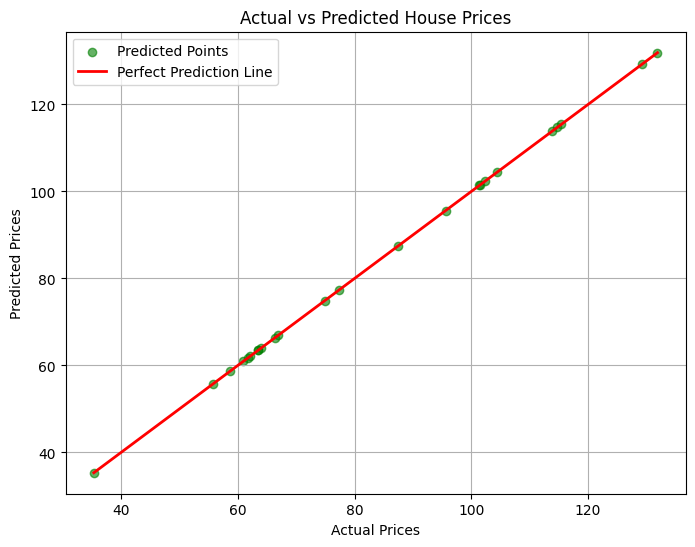

In [ ]:
plt.figure(figsize=(8,6))

# Scatter plot with custom color
plt.scatter(y_test, y_pred, color="green", alpha=0.6, label="Predicted Points")

# Reference line with different color
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2,
    label="Perfect Prediction Line"
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.legend()
plt.grid(True)

plt.show()


This code creates a scatter plot comparing actual prices with predicted prices, and draws a reference line to visually assess how closely the predictions match the real values.